# FYS-STK4155 - Project 1

In [3367]:
# --- Imports --- #

import numpy as np
import matplotlib.pyplot as plt
import sklearn
import jax
import jax.numpy as jnp
import pandas as pd

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

seed = 2026
np.random.seed(seed)
jax.config.update("jax_enable_x64", True)

### Exercise 1a:

In [3368]:
# --- Define functions needed for data-generation, scaling data, closed-form analytic solution and MSE/R2 error --- #

def runge(x):
    """Runge's function"""

    return 1/(1 + 25*x**2)

def closed_form(X, y, lam):
    "Closed form solution of the Ordinary Least Square method"

    n, p = X.shape
    return np.linalg.pinv(X.T @ X + n*lam*np.eye(p)) @ X.T @ y

def scale(X_train, X_test):
    """Scales training data, aswell as test data using mean and std of training data"""

    X_mean = X_train.mean(axis=0)
    X_std = X_train.std(axis=0)
    X_std[X_std == 0] = 1 
    X_train_norm = (X_train - X_mean) / X_std
    X_test_norm = (X_test - X_mean) / X_std 

    return X_train_norm, X_test_norm

def centre(y_train, y_test):
    """Centres training data, aswell as test data using mean of training data"""

    y_mean = y_train.mean()
    y_train_centered = y_train - y_mean
    y_test_centered = y_test - y_mean

    return y_train_centered, y_test_centered

def MSE(y, y_hat):
    """Function for calculating Mean Sqared ERROR between y and y_hat"""

    mse = 0
    n = len(y)

    for i in range(n):
        mse += (y[i,0] - y_hat[i,0])**2
    mse = mse/n

    y_mean = 0
    for i in range(n):
        y_mean += y[i,0]
    y_mean = y_mean/n

    return mse

def R_squared(y, y_hat):
    """Function for R2 ERROR between y and y_hat"""

    n = len(y)

    SSE = 0
    SST = 0

    y_mean = 0
    for i in range(n):
        y_mean += y[i,0]
    y_mean = y_mean/n

    for i in range(n):
        SSE += (y[i,0] - y_hat[i,0])**2
        SST += (y[i,0] - y_mean)**2

    R2_score = 1 - SSE/SST

    return R2_score

In [3369]:
# --- Setup Data --- #

def runge_data(n, sigma):
    """Function for generating data using the runge function"""
    
    np.random.seed(seed)
    x0, x1 = -1, 1

    x = np.linspace(x0, x1, n).reshape(-1, 1)
    y = runge(x) + np.random.normal(0, sigma, x.shape)

    training_portion = 3/5
    x_training, x_test, y_training, y_test = sklearn.model_selection.train_test_split(x, y, test_size=(1 - training_portion), random_state=seed)

    return x_training, x_test, y_training, y_test

n = 100
sigma = 0.1

x_training, x_test, y_training, y_test = runge_data(n, sigma)

In [3370]:
# --- Compute train and test MSE and R² for OLS at each polynomial degree --- #

def excercise_1a(x_training, x_test, y_training, y_test, p, lam):
    """Function for computing and storing theta_OLS and training/testing MSE and R2-score"""
    

    X_training = np.vander(x_training.reshape(-1), p, increasing=True)[:, 1:] 
    X_test = np.vander(x_test.reshape(-1), p, increasing=True)[:, 1:] 

    X_training, X_test = scale(X_training, X_test)
    y_training, y_test = centre(y_training, y_test)

    MSE_train = np.zeros(p - 1)
    MSE_test = np.zeros(p - 1)
    R2_train = np.zeros(p - 1)
    R2_test = np.zeros(p - 1)

    theta_OLS_list = np.zeros((p - 1, p - 1))

    for i in range(1, p):
        Xtr = X_training[:, :i]
        Xte = X_test[:, :i]

        theta_OLS = closed_form(Xtr, y_training, lam)
        theta_OLS_list[i - 1, :i] = theta_OLS.reshape(-1)

        y_hat_train = Xtr @ theta_OLS
        y_hat_test = Xte @ theta_OLS

        MSE_train[i - 1] = MSE(y_training, y_hat_train)
        MSE_test[i - 1] = MSE(y_test, y_hat_test)
        R2_train[i - 1] = R_squared(y_training, y_hat_train)
        R2_test[i - 1] = R_squared(y_test, y_hat_test)

    return theta_OLS_list, MSE_train, MSE_test, R2_train, R2_test

p = 16
lam = 0.0

theta_OLS_list, MSE_train, MSE_test, R2_train, R2_test = excercise_1a(x_training, x_test, y_training, y_test, p, lam)

In [3371]:
# --- Print the performance of the model --- #

def exercise_1a_print1(MSE_train, MSE_test, R2_train, R2_test):
    """Function for printing out the model performance and find best degree for model"""

    min_MSE_train = np.min(MSE_train)
    min_MSE_test = np.min(MSE_test)

    max_R2_train = np.max(R2_train)
    max_R2_test = np.max(R2_test)

    best_degree = np.argmin(MSE_test) + 1

    print("=" * 40)
    print("           MODEL PERFORMANCE")
    print("=" * 40)

    print(f"Minimum MSE (Train): {min_MSE_train:.4f}")
    print(f"Minimum MSE (Test):  {min_MSE_test:.4f}")

    print(f"Maximum R² (Train):  {max_R2_train:.4f}")
    print(f"Maximum R² (Test):   {max_R2_test:.4f}")

    print("-" * 40)
    print(f"Best model degree:    {best_degree}")
    print("=" * 40)

exercise_1a_print1(MSE_train, MSE_test, R2_train, R2_test)

           MODEL PERFORMANCE
Minimum MSE (Train): 0.0076
Minimum MSE (Test):  0.0194
Maximum R² (Train):  0.9211
Maximum R² (Test):   0.7156
----------------------------------------
Best model degree:    11


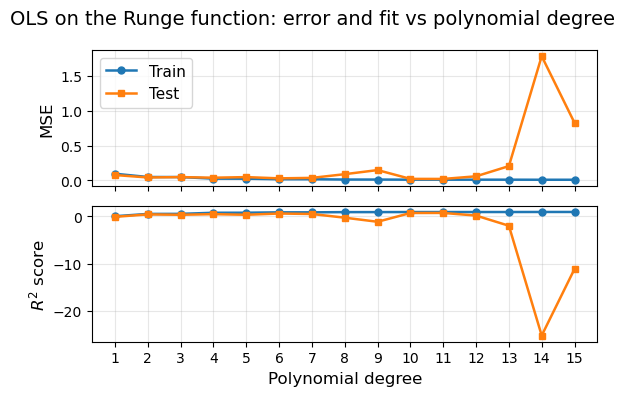

In [3372]:
# --- Plot of MSE and R2 --- #

def exercise_1a_plot1(MSE_train, MSE_test, R2_train, R2_test, p):
    """Function for plotting the training/testing MSE and R2-score depening on the polynomial degree"""
    
    degrees = np.arange(1, p)

    fig, (ax_mse, ax_R2) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

    ax_mse.plot(degrees, MSE_train, marker="o", markersize=5, linewidth=1.8, label="Train")
    ax_mse.plot(degrees, MSE_test, marker="s", markersize=5, linewidth=1.8, label="Test")
    ax_mse.set_ylabel("MSE", fontsize=12)
    ax_mse.grid(True, alpha=0.3)
    ax_mse.legend(fontsize=11)

    ax_R2.plot(degrees, R2_train, marker="o", markersize=5, linewidth=1.8, label="Train")
    ax_R2.plot(degrees, R2_test, marker="s", markersize=5, linewidth=1.8, label="Test")
    ax_R2.set_ylabel(r"$R^2$ score", fontsize=12)
    ax_R2.set_xlabel("Polynomial degree", fontsize=12)
    ax_R2.set_xticks(degrees)
    ax_R2.grid(True, alpha=0.3)  

    fig.suptitle("OLS on the Runge function: error and fit vs polynomial degree", fontsize=14)
    fig.tight_layout()
    plt.show()

exercise_1a_plot1(MSE_train, MSE_test, R2_train, R2_test, p)

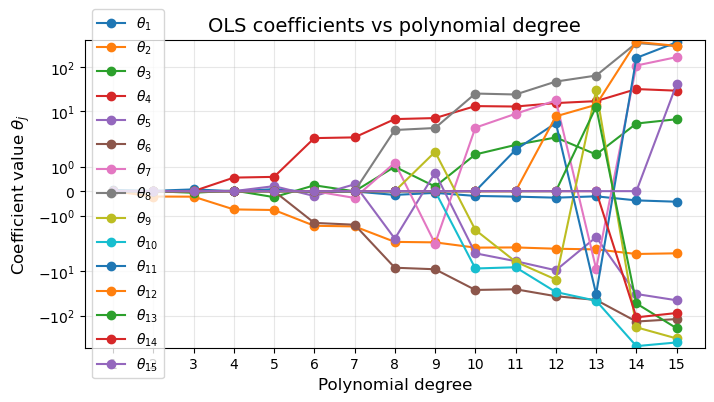

In [3373]:
# --- Plot how the thetas change as a function of complexity --- #

def excercise_1a_plot2(theta_OLS_list, p):
    """Function for plotting all thetas vs polynomial degree"""
    
    degrees = np.arange(1, p)

    plt.figure(figsize=(8, 4))
    for i in range(p - 1):
        plt.plot(degrees, theta_OLS_list[:, i], marker="o", label=rf"$\theta_{{{i + 1}}}$")

    plt.legend(loc="center left")
    plt.xlabel("Polynomial degree", fontsize=12)
    plt.ylabel(r"Coefficient value $\theta_j$", fontsize=12)
    plt.title("OLS coefficients vs polynomial degree", fontsize=14)
    plt.xticks(degrees)
    plt.yscale("symlog")
    plt.grid(True, alpha=0.3)
    plt.show()

excercise_1a_plot2(theta_OLS_list, p)

### Exercise 1b:

In [3374]:
# --- Compute train and test MSE and R² for Ridge Regression at each polynomial degree with different lambdas --- #

def exercise_1b(x_training, x_test, y_training, y_test, p, lambdas):
    """Function for computing and storing theta_ridge and training/test MSE and R2-score
    using ridge regression instead of OLS"""

    l = len(lambdas)

    MSE_train_b = np.zeros((p - 1, l))
    MSE_test_b = np.zeros((p - 1, l))
    R2_train_b = np.zeros((p - 1, l))
    R2_test_b = np.zeros((p - 1, l))

    theta_OLS_list_b = np.zeros((p - 1, p - 1, l))

    for i in range(l):
        theta_OLS_list, MSE_train, MSE_test, R2_train, R2_test = excercise_1a(x_training, x_test, y_training, y_test, p, lambdas[i])

        MSE_train_b[:, i] = MSE_train
        MSE_test_b[:, i] = MSE_test
        R2_train_b[:, i] = R2_train
        R2_test_b[:, i] = R2_test

        theta_OLS_list_b[:, :, i] = theta_OLS_list

    return theta_OLS_list_b, MSE_train_b, MSE_test_b, R2_train_b, R2_test_b

lambdas = [0, 0.01, 0.1, 1]
theta_OLS_list_b, MSE_train_b, MSE_test_b, R2_train_b, R2_test_b = exercise_1b(x_training, x_test, y_training, y_test, p, lambdas)

In [3375]:
# --- Print model performance for the Ridge Regression models using different lambdas --- #

def exercise_1b_print1(MSE_train_b, MSE_test_b, R2_train_b, R2_test_b):
    """Function for printing the model prefomances on the test data using different lambdas 
    with increasing polynomial degree"""

    print("=" * 40)

    print("              MODEL PERFORMANCE")

    print("=" * 40)

    for i in range(len(lambdas)):

        min_MSE_train = np.min(MSE_train_b[:, i])
        min_MSE_test = np.min(MSE_test_b[:, i])

        max_R2_train = np.max(R2_train_b[:, i])
        max_R2_test = np.max(R2_test_b[:, i])

        best_idx = np.argmin(MSE_test_b[:, i])
        best_degree = best_idx + 1

        print(f"Lambda = {lambdas[i]}")
        print(f"Minimum MSE (Train): {min_MSE_train:.4f}")
        print(f"Minimum MSE (Test):  {min_MSE_test:.4f}")
        print(f"Maximum R² (Train):  {max_R2_train:.4f}")
        print(f"Maximum R² (Test):   {max_R2_test:.4f}")
        print(f"Best model degree:   {best_degree}")

        print("-" * 40)

    print("=" * 40)

exercise_1b_print1(MSE_train_b, MSE_test_b, R2_train_b, R2_test_b)

              MODEL PERFORMANCE
Lambda = 0
Minimum MSE (Train): 0.0076
Minimum MSE (Test):  0.0194
Maximum R² (Train):  0.9211
Maximum R² (Test):   0.7156
Best model degree:   11
----------------------------------------
Lambda = 0.01
Minimum MSE (Train): 0.0236
Minimum MSE (Test):  0.0286
Maximum R² (Train):  0.7544
Maximum R² (Test):   0.5793
Best model degree:   14
----------------------------------------
Lambda = 0.1
Minimum MSE (Train): 0.0361
Minimum MSE (Test):  0.0286
Maximum R² (Train):  0.6240
Maximum R² (Test):   0.5795
Best model degree:   6
----------------------------------------
Lambda = 1
Minimum MSE (Train): 0.0587
Minimum MSE (Test):  0.0374
Maximum R² (Train):  0.3889
Maximum R² (Test):   0.4512
Best model degree:   2
----------------------------------------


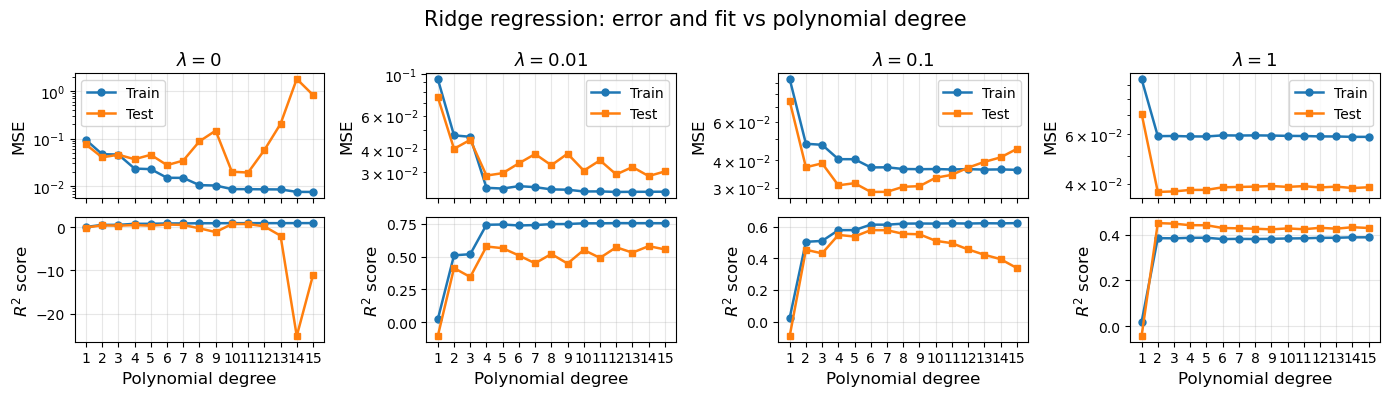

In [3376]:
# --- Plot multiple plots equal to amount of lambdas we are interested in showing how ridge regression error depends on both lambda and complexity --- #

def exercise_1b_plot1(MSE_train, MSE_test, R2_train, R2_test, p, lambdas):
    """Function for plotting MSE/R2-score vs complexity and with different
    lambdas"""

    degrees = np.arange(1, p)
    l = len(lambdas)

    fig, axes = plt.subplots(2, l, figsize=(3.5 * l, 4), sharex=True)

    if l == 1:
        axes = axes.reshape(2, 1)

    for i, lam in enumerate(lambdas):
        ax_mse = axes[0, i]

        ax_mse.plot(degrees, MSE_train[:, i], marker="o", markersize=5, linewidth=1.8, label="Train")
        ax_mse.plot(degrees, MSE_test[:, i], marker="s", markersize=5, linewidth=1.8, label="Test")

        ax_mse.set_title(rf"$\lambda = {lam}$", fontsize=13)
        ax_mse.set_ylabel("MSE", fontsize=12)
        ax_mse.grid(True, alpha=0.3)
        ax_mse.legend(fontsize=10)
        ax_mse.set_yscale("log")

        ax_R2 = axes[1, i]

        ax_R2.plot(degrees, R2_train[:, i], marker="o", markersize=5, linewidth=1.8, label="Train")

        ax_R2.plot(degrees, R2_test[:, i], marker="s", markersize=5, linewidth=1.8, label="Test")

        ax_R2.set_ylabel(r"$R^2$ score", fontsize=12)
        ax_R2.set_xlabel("Polynomial degree", fontsize=12)
        ax_R2.set_xticks(degrees)
        ax_R2.grid(True, alpha=0.3)

    fig.suptitle("Ridge regression: error and fit vs polynomial degree",fontsize=15)

    fig.tight_layout()
    plt.show()

exercise_1b_plot1(MSE_train_b, MSE_test_b, R2_train_b, R2_test_b, p, lambdas)

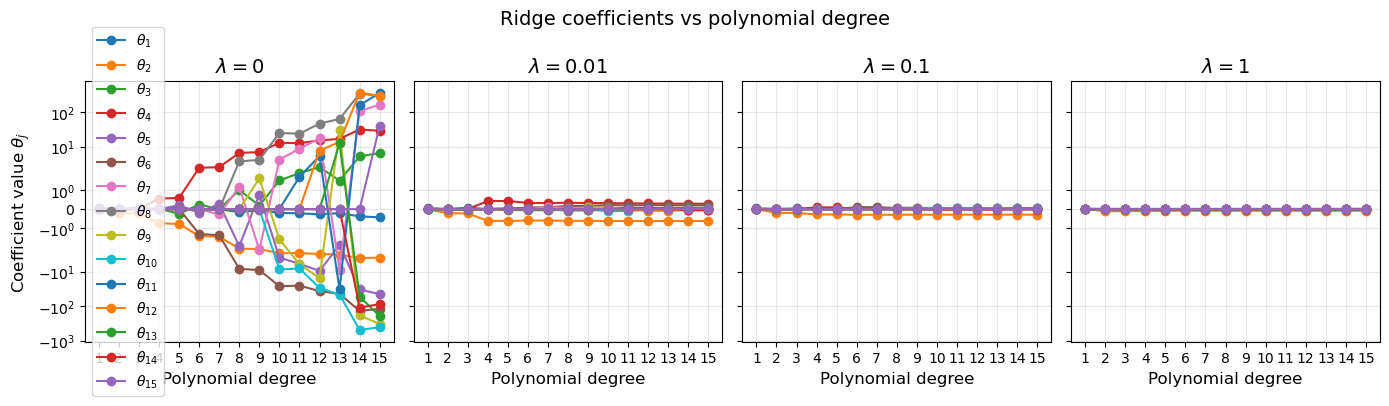

In [3377]:
# --- Plot multiple plots showing how theta changes as we increase complexity and with increasing lambda --- #

def excercise_1b_plot2(theta_OLS_list, p, lambdas):
    """Function for plotting the the thetas as we increase complexity
    and change lambda"""

    degrees = np.arange(1, p)

    fig, axes = plt.subplots(1, len(lambdas), figsize=(3.5 * len(lambdas), 4), sharey=True)

    for l in range(len(lambdas)):
        ax = axes[l]

        for i in range(p - 1):
            ax.plot(degrees, theta_OLS_list[:, i, l], marker="o", label=rf"$\theta_{{{i + 1}}}$")

        ax.set_xlabel("Polynomial degree", fontsize=12)
        ax.set_title(rf"$\lambda = {lambdas[l]}$", fontsize=14)
        ax.set_xticks(degrees)
        ax.set_yscale("symlog")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(r"Coefficient value $\theta_j$", fontsize=12)

    axes[0].legend(loc="center left")

    fig.suptitle("Ridge coefficients vs polynomial degree", fontsize=14)
    fig.tight_layout()
    plt.show()

excercise_1b_plot2(theta_OLS_list_b, p, lambdas)

### Exercise 1c:

In [3378]:
# --- Setup Data for Bias-Variance Plot --- #

n = 1000
sigma = 0.4

x_training, x_test, y_training, y_test = runge_data(n, sigma)

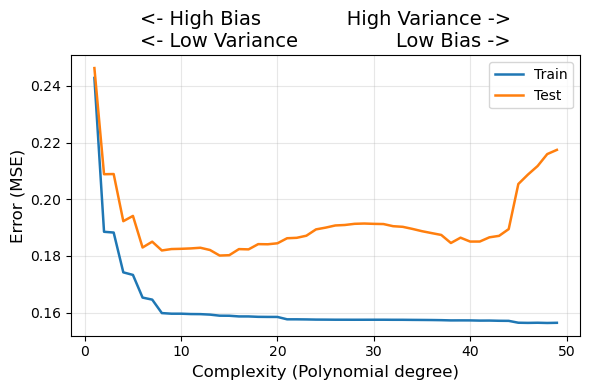

In [3379]:
# --- Plot MSE error vs model complexity to make simple showcase for the bias-variance tradeoff without finding bias and variance --- #

def excercise_1c_plot1(p):
    """Function for making a simple model of the bias variance tradeoff
    using only the MSE error and complexity"""

    degrees = np.arange(1, p)

    theta_OLS_list, MSE_train, MSE_test, R2_train, R2_test = excercise_1a(x_training, x_test, y_training, y_test, p, lam=0)

    plt.figure(figsize=(6, 4))
    plt.plot(degrees, np.ravel(MSE_train), markersize=5, linewidth=1.8, label="Train")
    plt.plot(degrees, np.ravel(MSE_test), markersize=5, linewidth=1.8, label="Test")
    plt.xlabel("Complexity (Polynomial degree)", fontsize=12)
    plt.ylabel("Error (MSE)", fontsize=12)
    plt.title("<- High Bias              High Variance ->\n<- Low Variance                Low Bias ->", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

p = 50
excercise_1c_plot1(p)

In [3380]:
# --- Restart Data for bootstrap method --- #

n = 100
sigma = 0.1

x_training, x_test, y_training, y_test = runge_data(n, sigma)

In [3381]:
# --- Using bootstrap method to find avereage test-error, bias and variance to showcase the bias variance tradeoff --- #

def exercise_1c(x_training, x_test, y_training, y_test, n_bootstrap, p, lam):
    """Function for using bootstrap method to find average test_error (MSE), 
    Bias and variance"""

    test_error = np.zeros(p - 1)
    bias = np.zeros(p - 1)
    variance = np.zeros(p - 1)

    for i in range(1, p):
        y_pred = np.zeros((len(x_test), n_bootstrap)) 

        for j in range(n_bootstrap):
            x_boot, y_boot = sklearn.utils.resample(x_training, y_training)

            x_boot_scaled, x_test_scaled = scale(x_boot, x_test)

            X_boot = np.zeros((len(x_boot_scaled), i + 1))
            X_test = np.zeros((len(x_test_scaled), i + 1))

            for k in range(len(x_boot_scaled)):
                for l in range(i + 1):
                    X_boot[k,l] = x_boot_scaled[k,0]**l

            for k in range(len(x_test_scaled)):
                for l in range(i + 1):
                    X_test[k,l] = x_test_scaled[k,0]**l

            theta_hat_OLS = closed_form(X_boot, y_boot, lam)
            y_test_hat = X_test @ theta_hat_OLS

            y_pred[:, j] = y_test_hat.ravel()
        
        test_error[i - 1] = np.mean((y_test.reshape(-1, 1) - y_pred) ** 2)
        bias[i - 1] = np.mean((y_test.reshape(-1, 1) - np.mean(y_pred, axis=1, keepdims=True)) ** 2)
        variance[i - 1] = np.mean(np.var(y_pred, axis=1))

    return test_error, bias, variance

p = 16
n_bootstrap = 50
lam = 0.0
test_error, bias, variance = exercise_1c(x_training, x_test, y_training, y_test, 50, p, lam)

0.03949248840252764
3


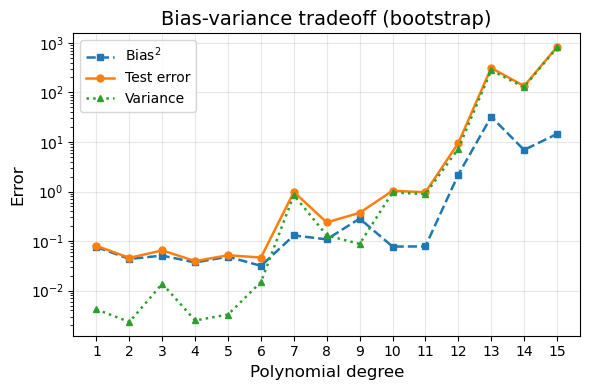

In [3382]:
# ---  Plot the bias-variance tradeoff as complexity increases --- #

def excercise_1c_plot2(test_error, bias, variance, p):
    """Function for plotting the Bias-variance trafeoff as
    a function of the model complexity"""

    degrees = np.arange(1, p)

    plt.figure(figsize=(6, 4))

    plt.plot(degrees, bias, marker="s", markersize=5, linewidth=1.8, linestyle="--", label=r"Bias$^2$")
    plt.plot(degrees, test_error, marker="o", markersize=5, linewidth=1.8, linestyle="-", label="Test error")
    plt.plot(degrees, variance, marker="^", markersize=5, linewidth=1.8, linestyle=":", label="Variance")

    plt.xlabel("Polynomial degree", fontsize=12)
    plt.ylabel("Error", fontsize=12)
    plt.title("Bias-variance tradeoff (bootstrap)", fontsize=14)
    plt.xticks(degrees)
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

print(min(test_error))
print(np.argmin(test_error))
excercise_1c_plot2(test_error, bias, variance, p)

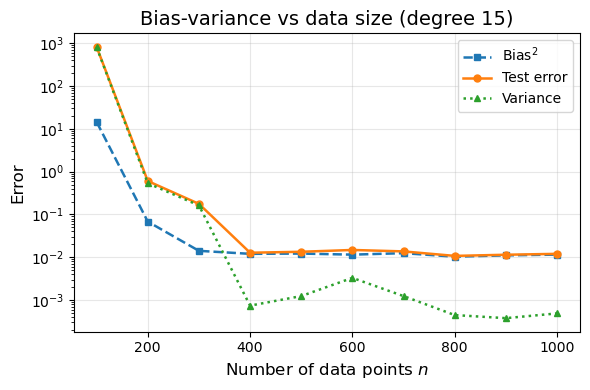

In [3383]:
# --- Plot the bias-variance tradeoff as a funtion of data points --- #

def excercise_1c_plot3(n_bootstrap, p, lam=0):
    """Function for plotting the Bias-variance trafeoff as
    a function the amount of data points used"""
    
    test_err_n = np.zeros(len(ns))
    bias_n = np.zeros(len(ns))
    var_n = np.zeros(len(ns))

    for i in range(len(ns)):
        x_training, x_test, y_training, y_test = runge_data(ns[i], sigma)
        test_error, bias, variance = exercise_1c(x_training, x_test, y_training, y_test, n_bootstrap, p, lam)

        test_err_n[i] = test_error[-1]
        bias_n[i] = bias[-1]
        var_n[i] = variance[-1]

    plt.figure(figsize=(6, 4))
    plt.plot(ns, bias_n, marker="s", markersize=5, linewidth=1.8, linestyle="--", label=r"Bias$^2$")
    plt.plot(ns, test_err_n, marker="o", markersize=5, linewidth=1.8, linestyle="-", label="Test error")
    plt.plot(ns, var_n, marker="^", markersize=5, linewidth=1.8, linestyle=":", label="Variance")
    plt.xlabel("Number of data points $n$", fontsize=12)
    plt.ylabel("Error", fontsize=12)
    plt.yscale("log")
    plt.title(f"Bias-variance vs data size (degree {p - 1})", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

ns = np.arange(1, 11) * 100
sigma = 0.1
excercise_1c_plot3(n_bootstrap, p, lam)

### Exercise 1d:

In [3384]:
# --- Defininf functions needed to perform cross-validation --- #

def k_fold(x, k):
    """Function for splitting data into K parts"""

    folds = (len(x) // k)
    split_indices = np.zeros(k + 1, dtype=int)

    for i in range(k):  
        split_indices[i] = (i)*folds

    split_indices[-1] = len(x)

    return split_indices

def cross_validation(x, y, k, p, lam):
    """Function for performing cross-validation of data"""

    k_indices = k_fold(x, k)
    mse_scores = np.zeros(k)

    for i in range(k):
        x_test = x[k_indices[i]:k_indices[i + 1]]
        y_test = y[k_indices[i]:k_indices[i + 1]]

        x_train = np.concatenate([x[0:k_indices[i]], x[k_indices[i + 1]:]])
        y_train = np.concatenate([y[0:k_indices[i]], y[k_indices[i + 1]:]])

        X_train = x_train[:, 0:1] ** np.arange(1, p)
        X_test = x_test[:, 0:1] ** np.arange(1, p)

        X_train, X_test = scale(X_train, X_test)
        y_train, y_test = centre(y_train, y_test)

        theta_hat = closed_form(X_train, y_train, lam)
        y_hat = X_test @ theta_hat

        mse_scores[i] = MSE(y_test, y_hat)

    mean_mse = np.mean(mse_scores)
    std_mse = np.std(mse_scores)

    return mean_mse, std_mse

In [3385]:
# --- Setup Shuffled Data for cross-validtaion --- #

n = 100
sigma = 0.1

np.random.seed(seed)
x0, x1 = -1, 1

x = np.linspace(x0, x1, n).reshape(-1, 1)
y = runge(x) + np.random.normal(0, sigma, x.shape)
idx = np.random.permutation(len(x))
x, y = x[idx], y[idx]

In [3386]:
# --- Perform cross-validation to estimate MSE as a function of degree and lambda --- #

def exercise_1d(x, y, k, p, lambdas):
    """Cross-validated MSE for degrees 1 to p-1 and every lambda."""

    cv_results = np.zeros((p - 1, len(lambdas), 2))

    for d in range(1, p):
        for j in range(len(lambdas)):
            cv_results[d - 1, j] = cross_validation(x, y, k, d + 1, lambdas[j])

    return cv_results

p = 16
k = 5
lambdas = [0, 0.01, 0.1, 0]
cv_results = exercise_1d(x, y, k, p, lambdas)

In [3387]:
# --- Perform cross-validation using SKlearn instead as a function of degree only for comparison --- #

def exercise_1d_sklearn(x, y, k, p, lam=0):
    """Same as exercise_1d() but using sklearn instead"""

    kf = KFold(n_splits=k, shuffle=False)     
    cv_results = np.zeros((p - 1, 2))

    for d in range(1, p):
        model = make_pipeline(PolynomialFeatures(d, include_bias=False), StandardScaler(), Ridge(alpha=lam))
        scores = -cross_val_score(model, x, y.ravel(), cv=kf, scoring="neg_mean_squared_error")
        cv_results[d - 1] = scores.mean(), scores.std()

    return cv_results

cv_sklearn = exercise_1d_sklearn(x, y, k, p, lambdas[0])

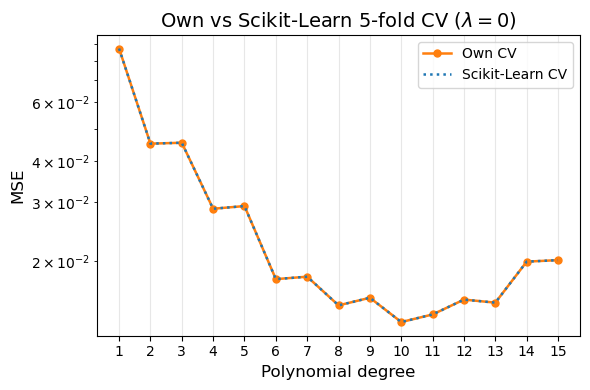

In [3388]:
# --- Plotting difference between self-made and SKlearn k-fold-cross-validation to verify that self-made version works --- #

def excercise_1d_plot1(cv_results, cv_sklearn, p):
    """Function for plotting self-made cross-validation with sklearn
    for comparison"""

    degrees = np.arange(1, p)

    plt.figure(figsize=(6, 4))
    plt.plot(degrees, cv_results[:, 0, 0], marker="o", markersize=5, linewidth=1.8, color="tab:orange", label="Own CV")
    plt.plot(degrees, cv_sklearn[:, 0], markersize=5, linewidth=1.8, linestyle=":", color="tab:blue", label="Scikit-Learn CV")
    plt.xlabel("Polynomial degree", fontsize=12)
    plt.ylabel("MSE", fontsize=12)
    plt.title(rf"Own vs Scikit-Learn {k}-fold CV ($\lambda = {lambdas[0]:g}$)", fontsize=14)
    plt.xticks(degrees)
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

excercise_1d_plot1(cv_results, cv_sklearn, p)

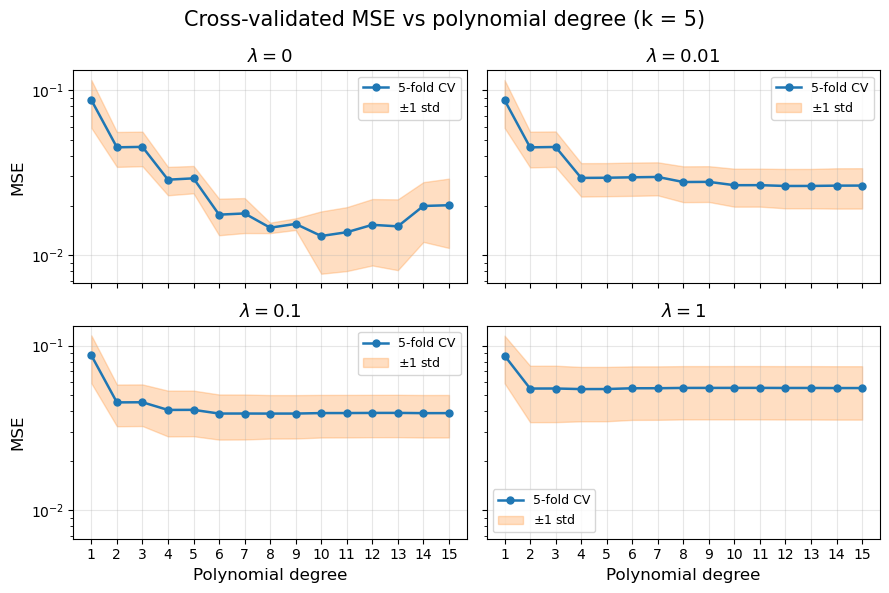

In [3389]:
# --- Plot cross-validated MSE as function of complexity for different lambdas --- #

def excercise_1d_plot2(cv_results, lambdas, p, k, lams=(0, 0.01, 0.1, 1)):
    """Function for plotting k-cross-validated MSE and STD as a function of
    the complexity"""

    degrees = np.arange(1, p)

    fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharex=True, sharey=True)

    for ax, lam in zip(axes.ravel(), lams):
        j = np.argmin(np.abs(lambdas - lam))          
        mean_mse = cv_results[:, j, 0]
        std_mse = cv_results[:, j, 1]
        lower = np.maximum(mean_mse - std_mse, 1e-12)   

        ax.plot(degrees, mean_mse, marker="o", markersize=5, linewidth=1.8, color="tab:blue", label=f"{k}-fold CV")
        ax.fill_between(degrees, lower, mean_mse + std_mse, color="tab:orange", alpha=0.25, label=r"$\pm 1$ std")
        ax.set_title(rf"$\lambda = {lambdas[j]:g}$", fontsize=13)
        ax.set_yscale("log")
        ax.set_xticks(degrees)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    for ax in axes[1]:
        ax.set_xlabel("Polynomial degree", fontsize=12)
    for ax in axes[:, 0]:
        ax.set_ylabel("MSE", fontsize=12)

    fig.suptitle(f"Cross-validated MSE vs polynomial degree (k = {k})", fontsize=15)
    fig.tight_layout()
    plt.show()

lambdas = np.array([0, 0.01, 0.1, 1])
cv_results = exercise_1d(x, y, k, p, lambdas)
excercise_1d_plot2(cv_results, lambdas, p, k)

### Exercise 1e:

In [3390]:
# --- Restart data --- #

n = 100
sigma = 0.1

np.random.seed(seed)
x0, x1 = -1, 1

x = np.linspace(x0, x1, n).reshape(-1, 1)
y = runge(x) + np.random.normal(0, sigma, x.shape)

In [3391]:
# --- Functions for finding identity matrix X, cost of OLS/Ridge, gradient of cost (self-made and JAX) and performing gradient descent --- #

def identity(x, p):
    """Function for finding idenity matrix of the data x with p features"""

    n = len(x)
    X = np.zeros((n, p))

    for i in range(n):
        for j in range(p):
            X[i,j] = x[i,0]**j
            
    return X

def cost(theta, X, y, lam):
    """Function for calculating cost of MSE"""

    n = X.shape[0]
    return jnp.mean((X @ theta - y) ** 2) + lam * jnp.sum(theta ** 2)

grad_jax_function = jax.grad(cost) # Jax gradient function for comparing to my own

def gradient(X, y, theta, lam):
    """Function for calulating gradient of the MSE cost function"""

    n = X.shape[0]
    return (2/n)*X.T @ (X @ theta - y) + 2*lam*theta

def gradient_descent(X, y, gamma, iterations, lam=0.0, tol=1e-8, theta_OLS=None):
    """Function for performing gradient descent"""
    
    n, n_features = X.shape
    y = y.ravel()                                  

    theta = np.zeros(n_features)
    theta_jax = jnp.zeros(n_features)

    theta_history = np.zeros((n_features, iterations))
    theta_history_jax = np.zeros((n_features, iterations))
    iters = 0

    for t in range(iterations):
        iters += 1
        grad = gradient(X, y, theta, lam)
        grad_jax = grad_jax_function(theta_jax, X, y, lam)

        theta = theta - gamma * grad
        theta_jax = theta_jax - gamma * grad_jax

        theta_history[:, t] = theta
        theta_history_jax[:, t] = np.asarray(theta_jax)

        if theta_OLS is None:
            converged = np.linalg.norm(grad) < tol and np.linalg.norm(grad_jax) < tol
        else:
            converged = (np.linalg.norm(theta_OLS - theta) < tol and np.linalg.norm(theta_OLS - np.asarray(theta_jax)) < tol)
        if converged:
            break

    return iters, theta_history[:, :iters], theta_history_jax[:, :iters]

In [3392]:
# --- Perform gradient descent with self-made gradient descent and JAX gradient descent --- #

def exercise_1e(x, y, p, gamma, n_iterations, lam):
    """Function for calulating how thetas change with gradient descent as function for iteration
    for both OLS and Ridge regression"""

    X = identity(x, p)
    theta_OLS = closed_form(X, y, 0.0).reshape(-1)
    iters, hist, hist_jax = gradient_descent(X, y, gamma, n_iterations, lam=0.0, theta_OLS=theta_OLS)
    norm_diff = np.linalg.norm(hist[:, -1] - hist_jax[:, -1])

    theta_ridge = closed_form(X, y, lam).reshape(-1)
    iters_ridge, hist_ridge, hist_jax_ridge = gradient_descent(X, y, gamma, n_iterations, lam=lam, theta_OLS=theta_ridge)
    norm_diff_ridge = np.linalg.norm(hist_ridge[:, -1] - hist_jax_ridge[:, -1])

    return iters, hist, hist_jax, norm_diff, iters_ridge, hist_ridge, hist_jax_ridge, norm_diff_ridge

n_iterations = 2000
gamma = 0.05
lam = 0.1
iters, hist, hist_jax, norm_diff, iters_ridge, hist_ridge, hist_jax_ridge, norm_diff_ridge = exercise_1e(x, y, p, gamma, n_iterations, lam)

In [3393]:
# --- Checking difference between self-made GD and JAX GD to verify that self-made version works --- #

def exercise_1e_print1(norm_diff, norm_diff_ridge, iters, iters_ridge, lam):

    print(f"norm of diff between theta_GD and theta_GD_JAX: {norm_diff:.2e} ({iters} iterations)")
    print(f"norm of diff between theta_GD and theta_GD_JAX (lam = {lam}): {norm_diff_ridge:.2e} ({iters_ridge} iterations)")

exercise_1e_print1(norm_diff, norm_diff_ridge, iters, iters_ridge, lam)

norm of diff between theta_GD and theta_GD_JAX: 2.10e-16 (2000 iterations)
norm of diff between theta_GD and theta_GD_JAX (lam = 0.1): 3.16e-17 (1518 iterations)


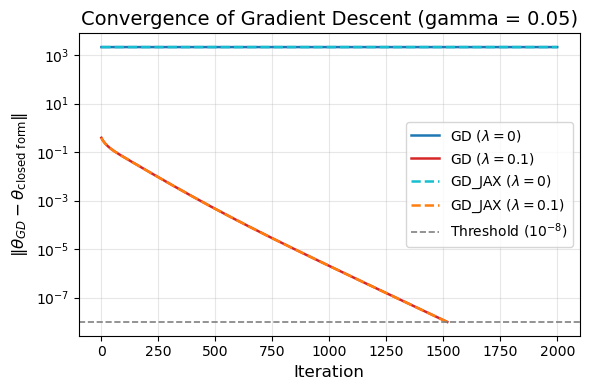

In [3394]:
# --- Plot how many iterations gradient descnet takes to reach the closed form solution using both self-made and JAX function --- #

def distance_to_ref(hist, theta_ref):
    """Find distance between a list of thetas and a thera referance point,
    usually the closed form solution"""

    return np.linalg.norm(hist - np.asarray(theta_ref).reshape(-1, 1), axis=0)

def excercise_1e_plot1(hist, hist_ridge, hist_jax, hist_jax_ridge, theta_OLS):
    """Function for plotting distance between thetas for every iteration and closed form theta"""

    plt.figure(figsize=(6, 4))
    plt.plot(distance_to_ref(hist, theta_OLS), linewidth=1.8, color="tab:blue", label=r"GD ($\lambda = 0$)")
    plt.plot(distance_to_ref(hist_ridge, theta_ridge), linewidth=1.8, color="tab:red", label=rf"GD ($\lambda = {lam}$)")
    plt.plot(distance_to_ref(hist_jax, theta_OLS), linewidth=1.8, linestyle="--", color="tab:cyan", label=r"GD_JAX ($\lambda = 0$)")
    plt.plot(distance_to_ref(hist_jax_ridge, theta_ridge), linewidth=1.8, linestyle="--", color="tab:orange", label=rf"GD_JAX ($\lambda = {lam}$)")
    plt.axhline(1e-8, color="gray", linestyle="--", linewidth=1.2, label=r"Threshold ($10^{-8}$)")
    plt.xlabel("Iteration", fontsize=12)
    plt.ylabel(r"$\|\theta_{GD} - \theta_{\mathrm{closed\ form}}\|$", fontsize=12)
    plt.title(f"Convergence of Gradient Descent (gamma = {gamma})", fontsize=14)
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

X = identity(x, p)
theta_OLS = closed_form(X, y, lam=0.0).reshape(-1)
theta_ridge = closed_form(X, y, lam).reshape(-1)
excercise_1e_plot1(hist, hist_ridge, hist_jax, hist_jax_ridge, theta_OLS)

In [3395]:
# --- Define functions for finding Hessian matrix, largest gamma that still makes GD converge and the optimal gamma for GD --- #

def hessian(X, lam=0.0):
    """Function for finding the hessian of the identity matrix X"""

    n, n_features = X.shape

    return (2/n)*(X.T @ X) + 2*lam*np.eye(n_features)

def gamma_limit(H):
    """Function for finding the max gamma that wont result in divergence"""

    eigenvalues = np.linalg.eigvalsh(H)

    return 2/np.max(eigenvalues)

def gamma_optimal(H):
    """Function for finding the optimal learning rate gamma"""

    eigenvalues = np.linalg.eigvalsh(H)

    return 2/(np.max(eigenvalues) + np.min(eigenvalues))

In [ ]:
# --- Find largest and lowest eigenvalues of the Hessian using both OLS and Ridge Regression to showcase how Ridge makes the Hessian far less ill-conditioned --- #

def exercise_1e_print2(H0, H, lam):
    """Function for printing largest and lowest eigenvalues of the Hessians H0 (lam=0)
    and H (lam=lambda)"""
    
    print(f"lambda = {0}")
    print("Largest eigenvalue:", np.max(np.linalg.eigvalsh(H0)))
    print("Smallest eigenvalue:", np.min(np.linalg.eigvalsh(H0)))
    print("")
    print(f"lambda = {lam}")
    print("Largest eigenvalue:", np.max(np.linalg.eigvalsh(H)))
    print("Smallest eigenvalue:", np.min(np.linalg.eigvalsh(H)))

p = 16
X = identity(x, p)
lam = 0.1
theta_ref = closed_form(X, y, lam).reshape(-1)
n_iterations = 1000
H = hessian(X, lam)
H0 = hessian(X, 0)
exercise_1e_print2(H0, H, lam)

lambda = 0
Largest eigenvalue: 2.53548770430383
Smallest eigenvalue: 2.957616012437652e-07

lambda = 1e-06
Largest eigenvalue: 2.5354897043038305
Smallest eigenvalue: 2.2957616013155224e-06


In [3397]:
# --- Perform gradient descent for different gammas, including the largest gamma for convergence, the lowest gamma for divergence and gamma for fastest gradient descent --- #

def exercise_1e_2(x, y, p, lam, n_iterations):
    """Functions for performing and storing theta histories using differen gammas"""

    X = identity(x, p)
    theta_ref = closed_form(X, y, lam).reshape(-1)

    gamma_max = gamma_limit(H)
    gamma_opt = gamma_optimal(H)
    gamma_converge = 0.98*gamma_max
    gamma_diverge = 1.02*gamma_max

    gammas = [0.01, 0.05, 0.1, gamma_opt, gamma_converge, gamma_diverge]

    hists = {}         
    iters_all = {}

    for gamma in gammas:
        iters, hist, hist_jax = gradient_descent(X, y, gamma, n_iterations, lam=lam, theta_OLS=theta_ref)
        hists[gamma] = hist
        iters_all[gamma] = iters

    return hists, iters_all, gamma_opt, gamma_converge, gamma_diverge, gammas

n_iterations = 1000
hists, iters_all, gamma_opt, gamma_converge, gamma_diverge, gammas = exercise_1e_2(x, y, p, lam, n_iterations)

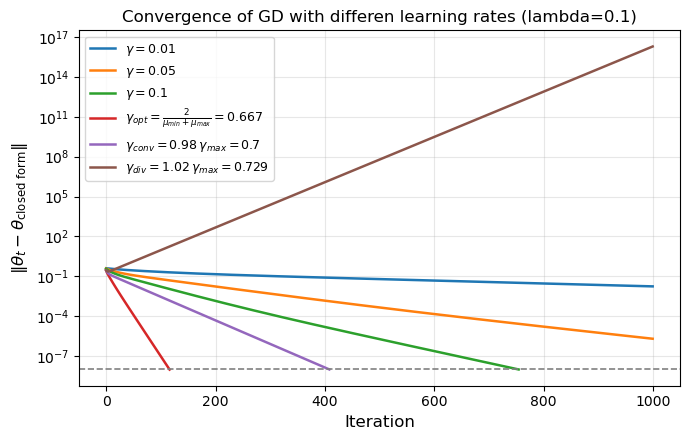

In [3398]:
# --- Plot distance to the theta_ref to theta_histories generated by GD with differing gammas --- #

def exercise_1e_plot2(hists, theta_ref, gamma_opt, gamma_converge, gamma_diverge, gammas):
    """Function for plotting distance to theta_closed and theta histories of gradient
    descents using different gammas"""

    labels = [
        rf"$\gamma = {gammas[0]:.3g}$",
        rf"$\gamma = {gammas[1]:.3g}$",
        rf"$\gamma = {gammas[2]:.3g}$",
        rf"$\gamma_{{opt}} = \frac{{2}}{{\mu_{{min}}+\mu_{{max}}}} = {gamma_opt:.3g}$",
        rf"$\gamma_{{conv}} = 0.98\,\gamma_{{max}} = {gamma_converge:.3g}$",
        rf"$\gamma_{{div}} = 1.02\,\gamma_{{max}} = {gamma_diverge:.3g}$",
    ]

    plt.figure(figsize=(7, 4.5))
    for gamma, label in zip(gammas, labels):
        plt.plot(distance_to_ref(hists[gamma], theta_ref), linewidth=1.8, label=label)
    plt.title(f"Convergence of GD with differen learning rates (lambda={lam})")
    plt.axhline(1e-8, color="gray", linestyle="--", linewidth=1.2)
    plt.xlabel("Iteration", fontsize=12)
    plt.ylabel(r"$\|\theta_t - \theta_{\mathrm{closed\ form}}\|$", fontsize=12)
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
    
exercise_1e_plot2(hists, theta_ref, gamma_opt, gamma_converge, gamma_diverge, gammas)

In [3399]:
# --- Print final distances to theta_closed and theta_GD for the different learning rates gamma --- #

def exercise_1e_print2(hists, theta_ref, gammas, tol=1e-8, div_tol=1e8):
    """Print whether each learning rate converged, and at which iteration."""

    print(f"{'gamma':>10} | {'status':<14} | {f'converged at iter':>17} | {'final distance':>14}")
    print("-" * 66)

    for gamma in gammas:
        d = np.asarray(distance_to_ref(hists[gamma], theta_ref), dtype=float)
        final = d[-1]
        below = np.where(d < tol)[0]

        if not np.isfinite(final) or final > div_tol:
            status, it = "diverged", "-"
        elif len(below) > 0:
            status, it = "converged", str(below[0] + 1)    
        else:
            status, it = "not converged", "-"

        print(f"{gamma:>10.4g} | {status:<14} | {it:>17} | {final:>14.3e}")

exercise_1e_print2(hists, theta_ref, gammas)

     gamma | status         | converged at iter | final distance
------------------------------------------------------------------
      0.01 | not converged  |                 - |      1.755e-02
      0.05 | not converged  |                 - |      2.029e-06
       0.1 | converged      |               755 |      9.921e-09
    0.6667 | converged      |               117 |      9.741e-09
    0.7001 | converged      |               409 |      9.970e-09
    0.7286 | diverged       |                 - |      1.919e+16


### Exercise 1f:

In [3400]:
# --- Restart and scale data --- #

x_training, x_test, y_training, y_test = runge_data(n=100, sigma=0.1)

x_training, x_test = scale(x_training, x_test)
y_training, y_test = centre(y_training, y_test)

In [3401]:
# --- Code for adaptive method (modified version of code given in exercise 38) --- #

def adaptive_method_step(method, theta, grad, vrm, gamma, t, beta=0.9, beta1=0.9, beta2=0.999, rho=0.99, eps=1e-8):
    """Function for performing 1 step using the Plain GD, Momentun, or the 3 adaptive methods"""

    if method == "PLAIN":                                   
        return theta - gamma*grad
    
    if method == "MOMENTUM":                                 
        vrm[0] = beta*vrm[0] + gamma*grad
        return theta - vrm[0]
    
    if method == "ADAGRAD":                                  
        vrm[1] = vrm[1] + grad**2
        return theta - (gamma*grad)/np.sqrt(vrm[1] + eps)
    
    if method == "RMSPROP":                                  
        vrm[1] = rho*vrm[1] + (1 - rho)*grad**2 
        return theta - (gamma*grad)/np.sqrt(vrm[1] + eps)
    
    if method == "ADAM":                                    
        vrm[2] = beta1*vrm[2] + (1 - beta1)*grad
        vrm[1] = beta2*vrm[1] + (1 - beta2)*grad**2
        m_hat, r_hat = vrm[2]/(1 - beta1**t), vrm[1]/(1 - beta2**t)
        return theta - (gamma*m_hat)/(np.sqrt(r_hat) + eps)

def adaptive_method(X, y, method, theta0, grad_function, gamma, num_iters=1000, lam=0.0, tol=1e-8, reverse_tol=1e8):
    """Function for performing Plain GD, Momentun, or the 3 adaptive methods"""

    theta_OLS = closed_form(X, y, lam).reshape(-1, 1)
    theta = np.array(theta0, dtype=float)
    
    vrm = np.zeros((3, len(theta)))
    hist = [theta.copy()]

    for t in range(1, num_iters + 1):
        grad = grad_function(X, y.reshape(-1), theta.reshape(-1), lam)
        theta = adaptive_method_step(method, theta, grad, vrm, gamma, t)
        hist.append(theta)

        if np.linalg.norm(theta_OLS.reshape(-1) - theta) < tol:
            break
        if np.linalg.norm(theta_OLS.reshape(-1) - theta) > reverse_tol:
            break

    return np.array(hist), t

In [3402]:
# --- Find theta_histories and error to the closed form solution using all the methods in the adaptive method using different degrees (complexity) --- #

def exercise_1f(p_list, methods, x_training, y_training, grad_function, gamma, lam):
    """Run every method for every p and store everything in a nested dict."""

    results = {}

    for p in p_list:
        theta0 = np.zeros(p)
        X = identity(x_training, p)
        theta_OLS = closed_form(X, y_training, lam)

        results[p] = {}
        for m in methods:
            hist, iters = adaptive_method(X, y_training, m, theta0, grad_function, gamma, lam=lam, num_iters=10000)
            error = np.linalg.norm(hist - theta_OLS.reshape(-1), axis=1)

            results[p][m] = {"history": hist, "error": error, "iterations": iters}

    return results

p_list = [3, 5, 7, 9]
lam = 0.1
gamma = 0.1
methods = ["PLAIN", "MOMENTUM", "ADAGRAD", "RMSPROP", "ADAM"]
results = exercise_1f(p_list, methods, x_training, y_training, gradient, gamma, lam)


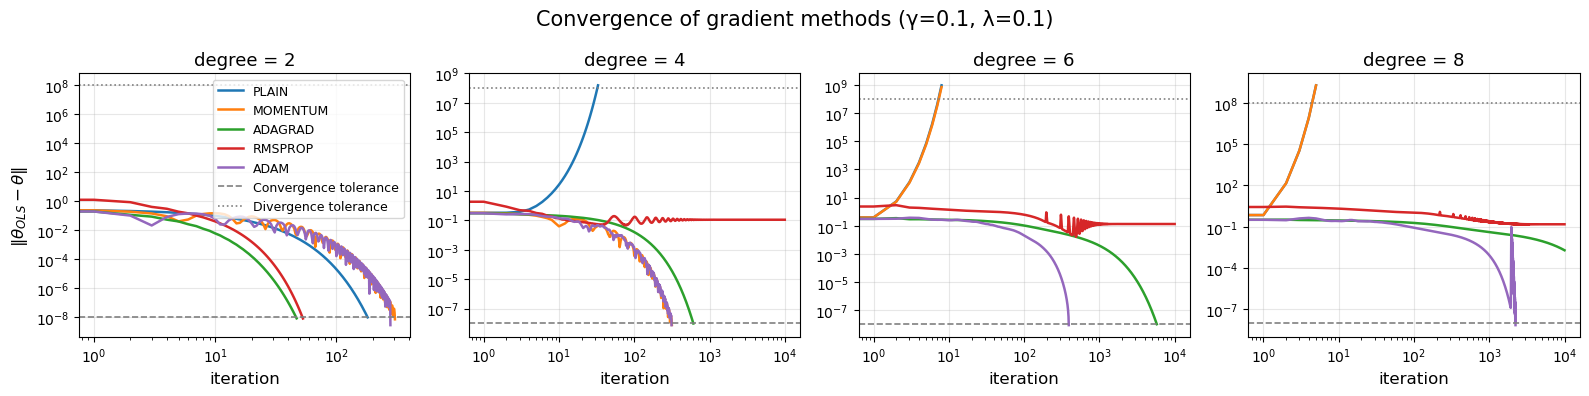

In [3403]:
# --- Plot the convergence/divergence of the different GD-methods with different complexity --- #

def exercise_1f_plot1(results, gamma, lam, show_divergence=True):
    """Plot stored results, one panel per p, one line per method."""
    
    p_list = list(results.keys())
    n = len(p_list)

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), squeeze=False)
    axes = axes[0]

    for ax, p in zip(axes, p_list):
        for m, res in results[p].items():
            error = res["error"]
            ax.plot(np.arange(len(error)), error, linewidth=1.8, label=m)

        ax.axhline(1e-8, color="gray", linestyle="--", linewidth=1.2, label="Convergence tolerance")
        if show_divergence:
            ax.axhline(1e8, color="gray", linestyle=":", linewidth=1.2, label="Divergence tolerance")

        ax.set_title(f"degree = {p - 1}", fontsize=13)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("iteration", fontsize=12)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(r"$\|\theta_{OLS} - \theta\|$", fontsize=12)
    axes[0].legend(fontsize=9)

    fig.suptitle(f"Convergence of gradient methods (γ={gamma}, λ={lam})", fontsize=15)
    fig.tight_layout()
    plt.show()

exercise_1f_plot1(results, gamma, lam)

### Exercise 1g:

In [3404]:
# --- Restart and scale data --- #

x_training, x_test, y_training, y_test = runge_data(n=100, sigma=0.1)

x_training, x_test = scale(x_training, x_test)
y_training, y_test = centre(y_training, y_test)

In [3405]:
# --- Define functions for finding 

def gradient_lasso(X, y, theta, lam):
    """Function for finding the subgradient of the Lasso cost.
    The derivative of abs(theta) isn't defined at theta = 0, so we use the
    subgradient sign(theta), which np.sign makes equal to 0 at theta = 0."""

    n = X.shape[0]
    return (2/n)*X.T @ (X @ theta - y) + lam*np.sign(theta)

def cost_lasso(theta, X, y, lam):
    """Cost function of Lasso regression"""

    return np.mean((X @ theta - y) ** 2) + lam * np.sum(np.abs(theta))

def exercise_1g(p_list, methods, x_training, y_training, grad_function, cost_function, gamma, lam):
    """Run every method for every p and store everything in a nested dict."""

    y = y_training
    results = {}

    for p in p_list:
        theta0 = np.zeros(p)
        X = identity(x_training, p)
        results[p] = {}
        for m in methods:
            hist, iters = adaptive_method(X, y, m, theta0, grad_function, gamma, lam=lam, num_iters=2000)
            hist = np.asarray(hist)
            cost = np.array([cost_function(th, X, y.reshape(-1), lam) for th in hist])
            results[p][m] = {"history": hist, "cost": cost, "iterations": iters}

    return results

lam = 1e-2
gamma = 0.01
methods = ["PLAIN", "MOMENTUM", "ADAGRAD", "RMSPROP", "ADAM"]
results = exercise_1g(p_list, methods, x_training, y_training, gradient_lasso, cost_lasso, gamma, lam)

In [3406]:
# --- Print the final gradient of the adaptive methods using lasso regression and compare them with SKlearns final gradient --- #

def exercise_1g_print1(x, y, lam, methods):
    """Print the final gradient of the adaptive methods and compare them w"""
    
    y = y.ravel()
    X = identity(x, 7)        
    m = sklearn.linear_model.Lasso(alpha=lam/2, fit_intercept=False, max_iter=1000, tol=1e-10).fit(X, y)
    cost_sk = cost_lasso(m.coef_, X, y, lam)

    print("Final gradinets:")
    print("SKLEARN   ", cost_sk)
    for meth in methods:
        c = results[7][meth]["cost"][-1]
        print(f"{meth:10s} {c:.6f}  (gap to sklearn: {c - cost_sk:.2e})")

exercise_1g_print1(x_training, y_training, lam, methods)

Final gradinets:
SKLEARN    0.03848016531764746
PLAIN      2534506402156615680.000000  (gap to sklearn: 2.53e+18)
MOMENTUM   0.038496  (gap to sklearn: 1.57e-05)
ADAGRAD    0.039185  (gap to sklearn: 7.05e-04)
RMSPROP    0.048779  (gap to sklearn: 1.03e-02)
ADAM       0.038514  (gap to sklearn: 3.43e-05)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.262e-09, tolerance: 5.765e-10
  model = cd_fast.enet_coordinate_descent(


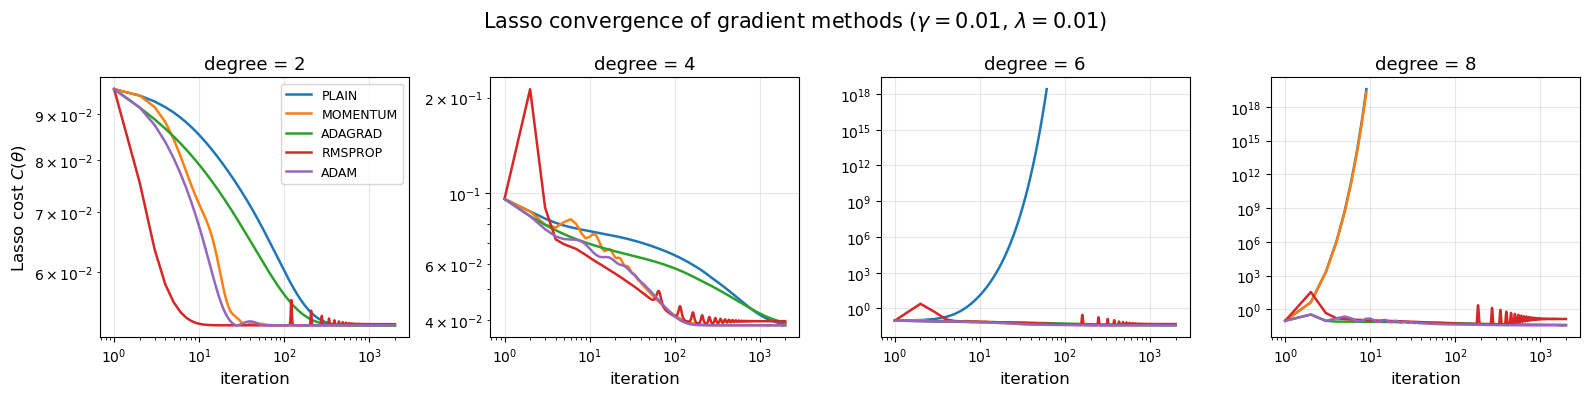

In [3407]:
# --- Plot the Lasso cost function of the different adaptive methods as a function of iteration for different complexity of the model --- #

def exercise_1g_plot1(results, gamma, lam):
    """Plot stored results: one panel per p, cost vs iteration, one line per method."""

    p_list = list(results.keys())
    n = len(p_list)

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), squeeze=False)
    axes = axes[0]

    for ax, p in zip(axes, p_list):
        for m, res in results[p].items():
            cost = np.asarray(res["cost"], dtype=float)
            cost[~np.isfinite(cost)] = np.nan  
            ax.plot(np.arange(1, len(cost) + 1), cost, linewidth=1.8, label=m)

        ax.set_title(f"degree = {p - 1}", fontsize=13)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("iteration", fontsize=12)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(r"Lasso cost $C(\theta)$", fontsize=12)
    axes[0].legend(fontsize=9)

    fig.suptitle(rf"Lasso convergence of gradient methods ($\gamma={gamma}$, $\lambda={lam}$)", fontsize=15)
    fig.tight_layout()
    plt.show()

exercise_1g_plot1(results, gamma, lam)

### Exercise 1h:

In [3408]:
# --- Restart and scale data --- #

x_training, x_test, y_training, y_test = runge_data(n=1000, sigma=0.1)

x_training, x_test = scale(x_training, x_test)
y_training, y_test = centre(y_training, y_test)

In [3409]:
# --- SGD methods from exercise week 38 --- #

def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches."""

    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def step_length(t, t0, t1):
    """The schedule of Eq. (4.40)."""

    return t0/(t + t1)

def sgd(X, y, theta0=None, method="PLAIN", grad_function=gradient, n_epochs=50, batch_size=5, gamma=0.1, schedule=None, lam=0.0, seed=2026):
    """Minibatch SGD, Eq. (4.34), with any optimiser. schedule=(t0, t1) replaces gamma by Eq. (4.40).
    Returns the iterate after every epoch."""

    rng = np.random.default_rng(seed)
    y = np.asarray(y).reshape(-1)
    n, p = X.shape

    if theta0 is None:
        theta = np.zeros(p)
    else:
        theta = theta0

    vrm, t = np.zeros((3, p)), 0
    history = [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = grad_function(X=X[batch], y=y[batch], theta=theta, lam=lam)

            if schedule is None:
                gamma_t = gamma
            else:
                t0, t1 = schedule
                gamma_t = step_length(t, t0, t1)      

            theta = adaptive_method_step(method, theta, g, vrm, gamma_t, t)
        history.append(theta.copy())
    return np.array(history)

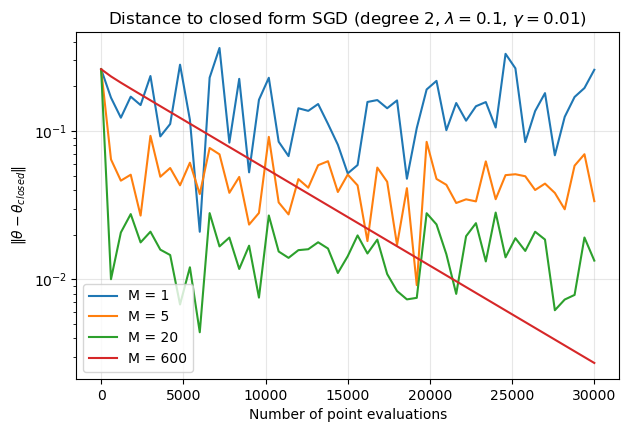

In [3410]:
# --- Plot SGD with different batch sizes with distance to closed form solution on the y-axis and number of single point evaluations on the x-axis --- #

def exercise_1g_plot1(x, y, p, epochs, lam):
    """Plot the SGD thetas distance to the closed form solution as functions of single point evaluations
    for different batch sizes M"""

    X = identity(x, p)
    y = y.ravel()
    n = X.shape[0]
    epochs = 50

    theta_OLS = closed_form(X, y, lam).reshape(-1)

    schedule = (1, 2)
    batch_sizes = [1, 5, 20, n]          
    x_evals = np.arange(epochs + 1) * n     

    plt.figure(figsize=(7, 4.5))
    for b in batch_sizes:
        hist = sgd(X, y, method="PLAIN", gamma=0.1, n_epochs=epochs, batch_size=b, lam=lam)
        dist = np.linalg.norm(hist - theta_OLS, axis=1)
        plt.plot(x_evals, dist, label=f"M = {b}")

    plt.xlabel("Number of point evaluations")
    plt.ylabel(r"$\|\theta - \theta_{closed}\|$")
    plt.title(rf"Distance to closed form SGD (degree {p-1}, $\lambda={lam}$, $\gamma={gamma}$)")
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

p = 3
lam = 0.1
epochs = 50
exercise_1g_plot1(x_training, y_training, p, epochs, lam)

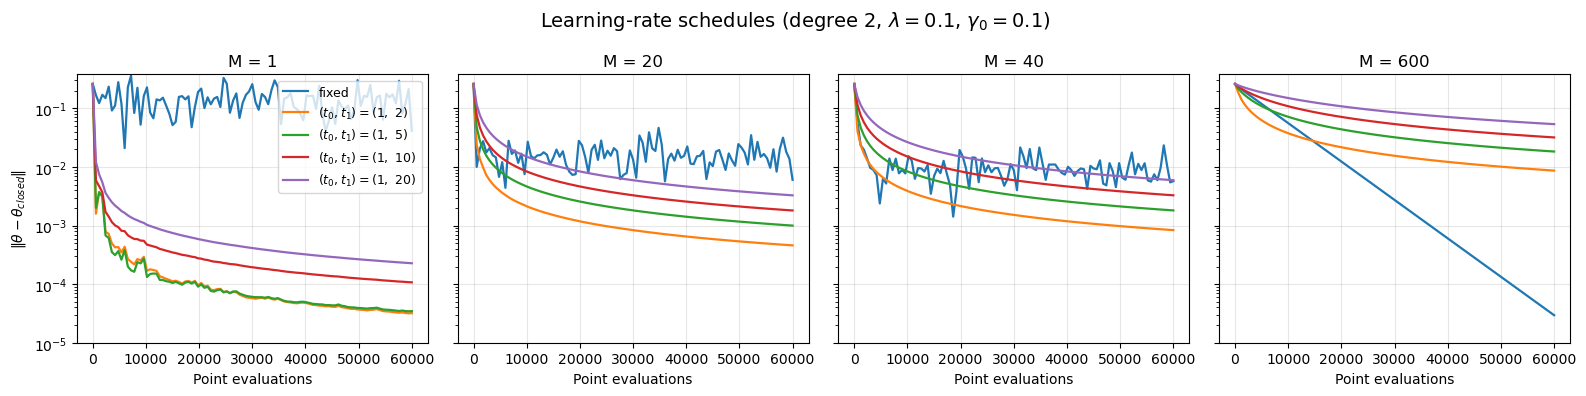

In [3411]:
# --- Plot multiple plots where each plots contains graphs showing SGD results with different schedules and eaxh plot has different batch size M --- #

def exercise_1g_plot2(x, y, p, epochs, lam):
    """Function for making different plots using different batch sizes
    of SGD. Each plots has multiple graphs using different schedules and
    the graphs show theta distance to closed form solution as function of
    iterations"""

    X = identity(x, p)
    y = y.ravel()
    n = X.shape[0]
    gamma0 = 0.1

    theta_OLS = closed_form(X, y, lam).reshape(-1)

    batch_sizes = [1, 20, 40, 600]
    x_evals = np.arange(epochs + 1) * n

    schedules = {"fixed": None}
    for t1 in [2, 5, 10, 20]:
        t0 = 1 
        schedules[rf"$(t_0, t_1) = ({t0:.2g},\ {t1})$"] = (t0, t1)

    fig, axes = plt.subplots(1, len(batch_sizes), figsize=(4 * len(batch_sizes), 4), sharey=True)

    for ax, b in zip(axes, batch_sizes):
        for label, sch in schedules.items():
            hist = sgd(X, y, method="PLAIN", gamma=gamma0, schedule=sch,
                    n_epochs=epochs, batch_size=b, lam=lam)
            dist = np.linalg.norm(hist - theta_OLS, axis=1)
            ax.plot(x_evals, dist, linewidth=1.6, label=label)

        ax.set_title(f"M = {b}")
        ax.set_xlabel("Point evaluations")
        ax.set_ylim(ymin=10e-6)
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(r"$\|\theta - \theta_{closed}\|$")
    axes[0].legend(fontsize=9)
    fig.suptitle(rf"Learning-rate schedules (degree {p-1}, $\lambda={lam}$, $\gamma_0={gamma0}$)", fontsize=14)
    fig.tight_layout()
    plt.show()

p = 3
lam = 0.1
epochs = 100
exercise_1g_plot2(x_training, y_training, p, epochs, lam)

### Exercise 1i:

In [3412]:
# --- Setup Shuffled Data --- #

n = 100
sigma = 0.1

np.random.seed(seed)
x0, x1 = -1, 1

x = np.linspace(x0, x1, n).reshape(-1, 1)
y = runge(x) + np.random.normal(0, sigma, x.shape)
idx = np.random.permutation(len(x))
x, y = x[idx], y[idx]

In [3413]:
# --- making new functions based on previous ones that make it easier to use them to find optimal p and lambda of OLS, Ridge and Lasso --- #

def fit_ols(X, y, lam):
    """Fit OLS by analytic solution"""

    return closed_form(X, y, 0.0).reshape(-1)

def fit_ridge(X, y, lam):
    """Fit ridge by analytic solution"""

    return closed_form(X, y, lam).reshape(-1)

def fit_lasso(X, y, lam, gamma=0.01, num_iters=3000):
    """Lasso by gradient descent with Adam, fixed number of iterations, start at zero."""

    theta = np.zeros(X.shape[1])
    vrm = np.zeros((3, X.shape[1]))
    for t in range(1, num_iters + 1):
        g = gradient_lasso(X, y, theta, lam)
        theta = adaptive_method_step("ADAM", theta, g, vrm, gamma, t)
    return theta

def cross_validation_fit(x, y, k, p, lam, fit):
    """Modified version of the previous cross_validation but with
    a parameter 'fit' so we can changhe methods for fitting theta"""

    k_indices = k_fold(x, k)
    mse_scores = np.zeros(k)

    for i in range(k):
        x_test = x[k_indices[i]:k_indices[i + 1]]
        y_test = y[k_indices[i]:k_indices[i + 1]]
        x_train = np.concatenate([x[0:k_indices[i]], x[k_indices[i + 1]:]])
        y_train = np.concatenate([y[0:k_indices[i]], y[k_indices[i + 1]:]])

        X_train = x_train[:, 0:1] ** np.arange(1, p)
        X_test = x_test[:, 0:1] ** np.arange(1, p)

        X_train, X_test = scale(X_train, X_test)
        y_train, y_test = centre(y_train, y_test)

        theta = fit(X_train, np.asarray(y_train).reshape(-1), lam)
        y_hat = X_test @ theta
        mse_scores[i] = np.mean((np.asarray(y_test).reshape(-1) - y_hat) ** 2)

    return np.mean(mse_scores), np.std(mse_scores)

In [3414]:
# --- Estimate optimal p and lambda for minimizing the MSE of the runge function for OLS, Ridge and Lasso --- #

def exercise_1i(x, y, degrees, lambdas, k=5):
    """Function for finding theta_OLS for each degree in degrees, aswell
    as optimal theta_ridge and theta_lasso depending on the best lambda in lambdas"""

    D, L = len(degrees), len(lambdas)
    ridge_grid = np.zeros((D, L, 2))
    lasso_grid = np.zeros((D, L, 2))
    rows = []

    for i, d in enumerate(degrees):
        p = d + 1
        ols_m, ols_s = cross_validation_fit(x, y, k, p, 0.0, fit_ols)

        for j, lam in enumerate(lambdas):
            ridge_grid[i, j] = cross_validation_fit(x, y, k, p, lam, fit_ridge)
            lasso_grid[i, j] = cross_validation_fit(x, y, k, p, lam, fit_lasso)

        jr = np.argmin(ridge_grid[i, :, 0])
        jl = np.argmin(lasso_grid[i, :, 0])
        rows.append({"Degree": d,
                     "OLS": ols_m,
                     "Ridge": ridge_grid[i, jr, 0], "Ridge lambda": lambdas[jr],
                     "Lasso": lasso_grid[i, jl, 0], "Lasso lambda": lambdas[jl]})

    table = pd.DataFrame(rows).set_index("Degree")
    return table, ridge_grid, lasso_grid

degrees = np.arange(1, 16)
lambdas = np.logspace(-6, 0, 13)

table, ridge_grid, lasso_grid = exercise_1i(x, y, degrees, lambdas, k=5)

In [3415]:
# --- Use results above to print and find the optimal parameters p and lambda to minimize runge MSE for OLS, Ridge and Lasso --- #


def exercise_1i_print1(table):
    """Function for printing out the table generated from exercise_1i()"""

    fmt = {"OLS": "{:.5f}", "Ridge": "{:.5f}", "Lasso": "{:.5f}",
           "Ridge lambda": "{:.0e}", "Lasso lambda": "{:.0e}"}
    out = table.copy()
    for col in ["OLS", "Ridge", "Lasso"]:
        best = table[col].idxmin()
        out[col] = [fmt[col].format(v) + (" *" if d == best else "") for d, v in table[col].items()]
    for col in ["Ridge lambda", "Lasso lambda"]:
        out[col] = [fmt[col].format(v) for v in table[col]]
    print("Cross-validated MSE per degree (best lambda for Ridge and Lasso, * = best of column)\n")
    print(out.to_string())
    print("\nBest model per method:")
    for col in ["OLS", "Ridge", "Lasso"]:
        d = table[col].idxmin()
        extra = f", lambda = {table.loc[d, col + ' lambda']:.0e}" if col != "OLS" else ""
        print(f"  {col:6s} degree {d}, CV MSE = {table.loc[d, col]:.5f}{extra}")

exercise_1i_print1(table)

Cross-validated MSE per degree (best lambda for Ridge and Lasso, * = best of column)

              OLS      Ridge Ridge lambda      Lasso Lasso lambda
Degree                                                           
1         0.08726    0.08691        1e+00    0.08659        1e-01
2         0.04508    0.04505        3e-02    0.04496        3e-02
3         0.04536    0.04522        3e-02    0.04495        3e-02
4         0.02869    0.02867        1e-03    0.02849        3e-03
5         0.02923    0.02895        3e-03    0.02862        3e-03
6         0.01760    0.01760        1e-05    0.01756        1e-06
7         0.01790    0.01783        1e-04    0.01765        3e-04
8         0.01467    0.01459        1e-05    0.01699        3e-06
9         0.01547    0.01489        1e-05    0.01707        1e-06
10      0.01307 *  0.01255 *        1e-06  0.01624 *        1e-04
11        0.01377    0.01263        1e-06    0.01630        1e-04
12        0.01527    0.01295        3e-06    0.01693    

In [3416]:
def exercise_1i_print2(x, y, table):
    """Print the theta vector of the best Lasso model."""

    d = table["Lasso"].idxmin()
    lam = table.loc[d, "Lasso lambda"]

    X = scale(x[:, 0:1] ** np.arange(1, d + 1), x[:, 0:1] ** np.arange(1, d + 1))[0]
    yc = np.asarray(centre(y, y)[0]).reshape(-1)

    theta = fit_lasso(X, yc, lam)

    print(f"Best Lasso model: degree {d}, lambda = {lam:.0e}")
    for k, t in enumerate(theta, start=1):
        print(f"  theta_{k:<2d} (x^{k:<2d}) = {t: .6f}")

exercise_1i_print2(x, y, table)

Best Lasso model: degree 10, lambda = 1e-04
  theta_1  (x^1 ) = -0.025033
  theta_2  (x^2 ) = -1.541226
  theta_3  (x^3 ) =  0.100355
  theta_4  (x^4 ) =  3.129837
  theta_5  (x^5 ) = -0.058716
  theta_6  (x^6 ) = -1.577624
  theta_7  (x^7 ) = -0.010816
  theta_8  (x^8 ) = -1.272582
  theta_9  (x^9 ) = -0.000473
  theta_10 (x^10) =  1.033629
